# Seaborn & Advanced Plotting

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. This notebook covers:
*   Scatter Plots (relationship and correlation between numerical variables)
*   Box Plots (outlier detection and quartile analysis)
*   Correlation vs. Covariance
*   Seaborn syntax conventions and `hue` grouping parameters.

## Scatter Plot
WE ONLY USE NUMERIC COULUMS   
     1. Can find    
        o -> Outliers      
        o -> Co-relation     
To detect Outliers we can use Boxplot,Z-Score
Co-relation and Covariance
In co-relation we can find multiple columns relation but not in covariance (only two)      
In co-relation we can tell how strong is the relationship  between Columns (dependency)  

In [1]:
import pandas as pd 
playstore=pd.read_csv("googleplaystore.csv")
playstore.drop_duplicates()
playstore=playstore.dropna(subset=['Rating','Type','Price'])
playstore['Installs']=playstore['Installs'].str.replace(',','')
playstore['Installs']=playstore['Installs'].str.replace('+','')
playstore = playstore[playstore['Installs'] != 'Free']
playstore['Installs']=playstore['Installs'].astype(int)
playstore['Price'] = playstore['Price'].str.replace('$', '')
playstore['Price'] = playstore['Price'].astype(float)
playstore['Last Updated']=pd.to_datetime(playstore['Last Updated'])
playstore['year']=playstore['Last Updated'].dt.year

# syntax:  
   ## plt.scatter(x,y)
   

In [2]:
import matplotlib.pyplot as plt


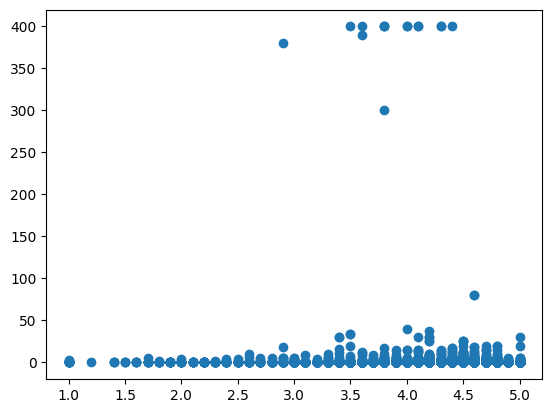

In [3]:
plt.scatter(playstore['Rating'],playstore['Price'])

In [4]:
playstore.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'year'],
      dtype='object')

In [5]:
playstore.corr(numeric_only=True)

,Rating,Installs,Price,year
Rating,1.000000,0.051355,-0.021903,0.137714
Installs,0.051355,1.000000,-0.011890,0.092645
Price,-0.021903,-0.011890,1.000000,-0.003379
year,0.137714,0.092645,-0.003379,1.000000


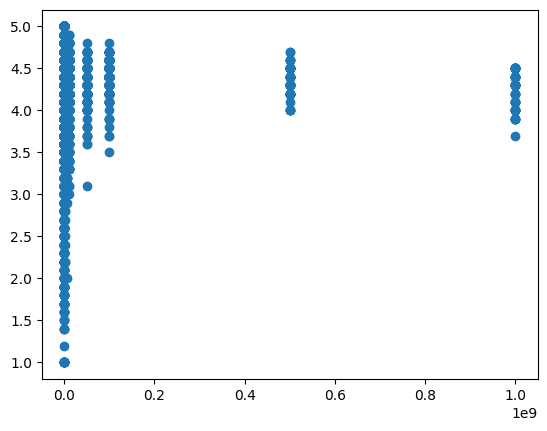

In [6]:
plt.scatter(playstore['Installs'],playstore['Rating'])

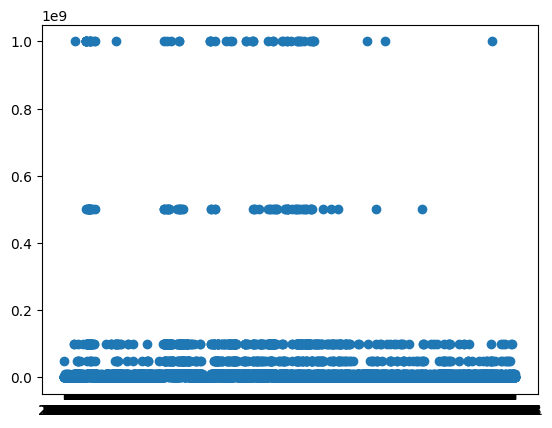

In [7]:
plt.scatter(playstore['Reviews'],playstore['Installs'])

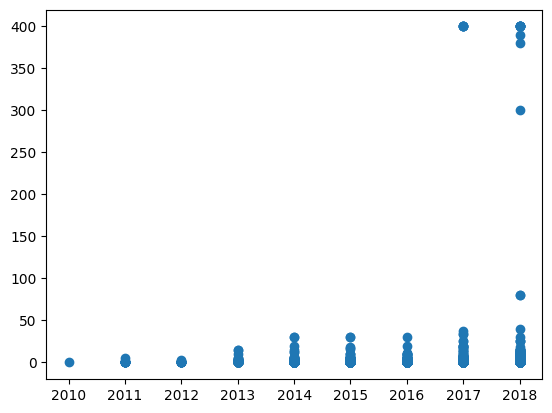

In [8]:
plt.scatter(playstore['year'],playstore['Price'])

## Outliers 
   1. Z-Score -  "x-U/o-"
   2. IQR
   3. Boxplot

Variance-Tells how the actual values are far from the mean 
if the values are  farfrom the mean -HIgh variance
if the values are near to mean - low variance

# Z-Score

In [9]:
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2018


In [43]:
# outliers=[]
# def zscore():

#     mean=playstore['Rating'].mean()
#     std=playstore['Rating'].std()
#     for val in playstore['Rating']:
#         z=(val-mean)/std
#         if abs(z)>3:
#             outliers.append(val)

  

# zscore()
# print(outliers)
# for i in outliers:
#     count=0
#     count+=1
#     print(count)







In [44]:
playstore['Rating']

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10834    4.0
10836    4.5
10837    5.0
10839    4.5
10840    4.5
Name: Rating, Length: 9366, dtype: float64

In [45]:
# def Z_score(col):
#     x=playstore[col]
#     x_mean= x.mean()
#     x_std=x.std()
#     return (x- x_mean)/x_std
# #Z_score(playstore['Rating'])
# playstore['Rating_Z'] = Z_score('Rating')
# playstore['Rating_Z']

In [48]:
def Z_score(col):
    x=playstore[col]
    x_mean= playstore[col].mean()
    x_std=playstore[col].std()
    return (x- x_mean)/x_std
#Z_score(playstore['Rating'])
playstore['Rating_Z'] = Z_score('Rating')
outliers=playstore[abs(playstore['Rating_Z'])>3]
playstore['Rating_Z']
print(len(outliers))

175


In [50]:
playstore.dropna()
# playstore['Rating_Z'].dropna


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,year,Rating_Z
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018,-0.178094
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018,-0.566279
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,2018,0.986460
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,2018,0.598275
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2018,0.210090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500,Free,0.0,Everyone,Education,2017-06-18,1.0.0,4.1 and up,2017,-0.372186
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,2017,0.598275
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,2018,1.568736
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,2015,0.598275


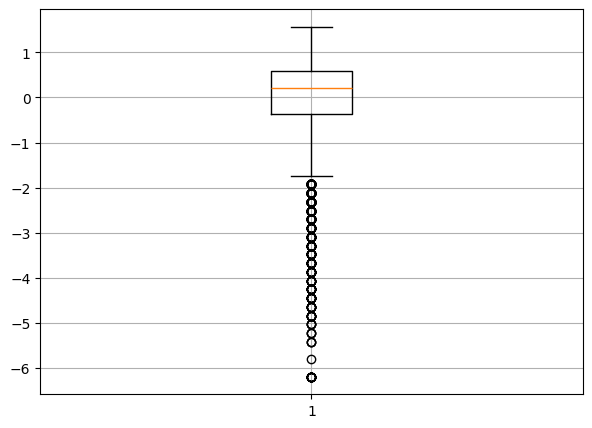

In [57]:
plt.figure(figsize=(7,5))#accepts only tuple(width,height)
plt.boxplot(playstore['Rating_Z'])
plt.grid()

In [ ]:
# # Conform the q1 q2 q3 
# Find the outliers :
#  1.Rating
#  2.

## SEABORN AND MATPLOTLIB

In [1]:
import seaborn as sns

---
## 🎨 Seaborn vs Matplotlib Syntax Comparison

*(This section is consolidated from `seabornn.ipynb`)*

differenc between seaborn and matplotlib
1.sns.lineplot(x=colname,y=colname,hue=category)
2.sns.lineplot(x=colname,y=colname,data=dataframe,hue=category)


In [1]:
import seaborn as sns